In [22]:

import numpy as np

from Kea.statistics.spectra import per_spectra, spectra_base, strfn_spectra
from Kea.statistics.statfunc import statfunc_base, strfn
from Kea.statistics import statistics_base
from Kea.utils import plotting, data_writer

import h5py as h5

import time

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plotting.modify_rc()


In [23]:
## REQUIRE MEMORY

P = 32
px = 16

Nx = 4096
Ny = 1
Nz = 4096

n = 1

# formulae
M2_s = (20 + 4*n)*Nx*Nz + 8*(Nx/px + Nz*px/P) + 32*P
M3_s = (16 + 2*n)*Nx*Ny*Nz + 4*Nx*Ny + 8*(Nx/px + Nz*px/P) + 40*P

M2_v = (44 + 8*n)*Nx*Nz + 8*(Nx/px + Nz*px/P) + 40*P
M3_v = (56 + 4*n)*Nx*Ny*Nz + 4*Nx*Ny + 8*(Nx/px + Nz*px/P) + 48*P

# IN GB
print('Scalar')
print(M2_s/1000/1000, 'MB')
print(P*M2_s/1000/1000, 'MB')

print('Vector')
print(M2_v/1000/1000/1000, 'MB')
print(P*M2_v/1000/1000/1000, 'MB')


Scalar
402.67264 MB
12885.52448 MB
Vector
0.872434944 MB
27.917918208 MB


In [24]:

SCALINGS = [
    {'N': 1024, 'P': 128, 'D': 2, 'T': 85.021, 'class': 'FBM', 'MaxRSS': 41568},
    {'N': 1024, 'P': 64, 'D': 2, 'T': 125.215, 'class': 'FBM', 'MaxRSS': 38540},
    {'N': 1024, 'P': 32, 'D': 2, 'T': 216.534, 'class': 'FBM', 'MaxRSS': 322460},
    {'N': 1024, 'P': 16, 'D': 2, 'T': 536.624, 'class': 'FBM', 'MaxRSS': 477828},

    {'N': 2048, 'P': 128, 'D': 2, 'T': 1331.89, 'class': 'FBM', 'MaxRSS': 678624, 'mem': 910.73},
    {'N': 2048, 'P': 64, 'D': 2, 'T': 2183.62, 'class': 'FBM', 'MaxRSS': 122856, 'mem': 757.22},
    {'N': 2048, 'P': 32, 'D': 2, 'T': 4221.57, 'class': 'FBM', 'MaxRSS': None, 'mem': None},

    # {'N': 4096, 'P': 128, 'D': 2, 'T': None, 'class': 'FBM', 'MaxRSS': None},
    # {'N': 4096, 'P': 64, 'D': 2, 'T': None, 'class': 'FBM', 'MaxRSS': None},
    # {'N': 4096, 'P': 32, 'D': 2, 'T': None, 'class': 'FBM', 'MaxRSS': None},

    {'N': 128, 'P': 128, 'D': 3, 'T': 110.947, 'class': 'FBM', 'MaxRSS': 58244, 'mem': 360.08},
    {'N': 128, 'P': 64, 'D': 3, 'T': 172.174, 'class': 'FBM', 'MaxRSS': 62684, 'mem': 403.69},
    {'N': 128, 'P': 32, 'D': 3, 'T': 363.825, 'class': 'FBM', 'MaxRSS': 58244, 'mem': 293.87},

    {'N': 256, 'P': 128, 'D': 3, 'T': 7607.52, 'class': 'FBM', 'MaxRSS': 316976, 'mem': 1350.},
    {'N': 256, 'P': 64, 'D': 3, 'T': 14838.7, 'class': 'FBM', 'MaxRSS': None, 'mem': None},
    #{'N': 256, 'P': 32, 'D': 3, 'T': None, 'class': 'FBM', 'MaxRSS': None},
]


[  2.14255708 -24.64646105] [  1.84986241 -21.07036757] [  1.74767834 -20.02711394]


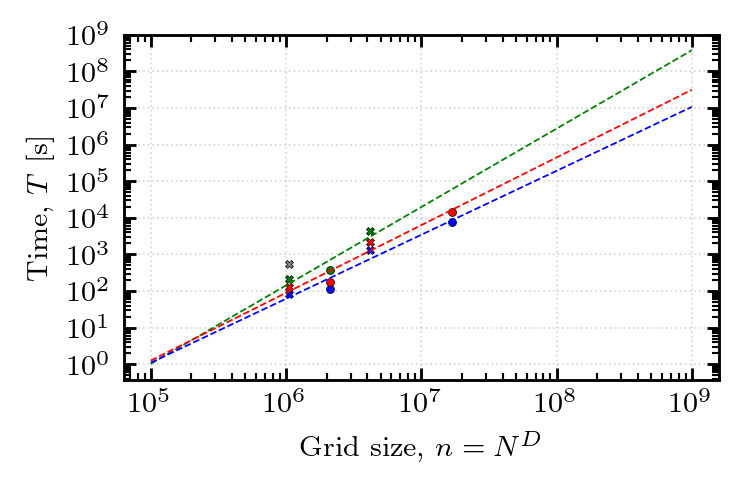

In [25]:

fig, ax = plt.subplots(1, 1, figsize=(3., 1.75), dpi=256)

#markers = {'FBM': 'X', 'SIM': 'o'}
markers = {1: 'v', 2: 'X', 3: 'o'}
colors = {16: 'gray', 32: 'green', 64: 'red', 128: 'blue'}

x_all, y_all = [], []
x_32, y_32 = [], []
x_64, y_64 = [], []
x_128, y_128 = [], []

for s in SCALINGS:
    x_all.append(s['N']**s['D'])
    y_all.append(s['T'])

    if s['P'] == 32:
        x_32.append(x_all[-1])
        y_32.append(y_all[-1])
    elif s['P'] == 64:
        x_64.append(x_all[-1])
        y_64.append(y_all[-1])
    elif s['P'] == 128:
        x_128.append(x_all[-1])
        y_128.append(y_all[-1])

    ax.scatter(s['N']**s['D'], s['T'], marker=markers[s['D']], s=5., color=colors[s['P']], zorder=2, linewidth=0.2, edgecolor='black')

f_all = np.polyfit(np.log(x_all), np.log(y_all), deg=1)
p_all = np.poly1d(f_all)

f_32 = np.polyfit(np.log(x_32), np.log(y_32), deg=1)
p_32 = np.poly1d(f_32)
f_64 = np.polyfit(np.log(x_64), np.log(y_64), deg=1)
p_64 = np.poly1d(f_64)
f_128 = np.polyfit(np.log(x_128), np.log(y_128), deg=1)
p_128 = np.poly1d(f_128)

print(f_32, f_64, f_128)

C = ['green', 'red', 'blue']
N = 10**np.linspace(np.log10(1e5), np.log10(1e9), 1000)
for i, f in enumerate([p_32, p_64, p_128]):
    ax.plot(N, np.exp(f(np.log(N))), linewidth=0.5, linestyle='--', color=C[i])

# t_est_64 = np.exp(p_64(np.log(1024**3)))
# t_est_128 = np.exp(p_128(np.log(1024**3)))
# print('Estimated time for 1024^3, 64 cores:', t_est_64/60./60./24., '[days]')
# print('Estimated time for 1024^3, 128 cores:', t_est_128/60./60./24., '[days]')
# # ax.scatter(1024**3, t_est_64, marker=markers[3], s=5., color='none', zorder=2, linewidth=0.5, edgecolor='red')
# # ax.scatter(1024**3, t_est_128, marker=markers[3], s=5., color='none', zorder=2, linewidth=0.5, edgecolor='blue')

# t_est_64 = np.exp(p_64(np.log(8192**2)))
# t_est_128 = np.exp(p_128(np.log(8192**2)))
# print('Estimated time for 8000^2, 64 cores:', t_est_64/60./60./24., '[days]')
# print('Estimated time for 8000^2, 128 cores:', t_est_128/60./60./24., '[days]')
# # ax.scatter(8192**2, t_est_64, marker=markers[2], s=5., color='none', zorder=2, linewidth=0.5, edgecolor='red')
# # ax.scatter(8192**2, t_est_128, marker=markers[2], s=5., color='none', zorder=2, linewidth=0.5, edgecolor='blue')

# t_est_64 = np.exp(p_64(np.log(16384**2)))
# t_est_128 = np.exp(p_128(np.log(16384**2)))
# print('Estimated time for 16000^2, 64 cores:', t_est_64/60./60./24., '[days]')
# print('Estimated time for 16000^2, 128 cores:', t_est_128/60./60./24., '[days]')
# # ax.scatter(16384**2, t_est_64, marker=markers[2], s=5., color='none', zorder=2, linewidth=0.5, edgecolor='red')
# # ax.scatter(16384**2, t_est_128, marker=markers[2], s=5., color='none', zorder=2, linewidth=0.5, edgecolor='blue')


# props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
# ax.text(1.5e7, 0.6, '32 Cores', color='green', transform=ax.get_xaxis_transform(), bbox=props, rotation=27.5)
# ax.text(1.5e8, 0.725, '64 Cores', color='red', transform=ax.get_xaxis_transform(), bbox=props, rotation=27.5)
# ax.text(1.5e8, 0.58, '128 Cores', color='blue', transform=ax.get_xaxis_transform(), bbox=props, rotation=27.5)

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')

locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
ax.yaxis.set_major_locator(locmaj)
locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
ax.yaxis.set_minor_locator(locmin)

locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
ax.xaxis.set_major_locator(locmaj)
locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
ax.xaxis.set_minor_locator(locmin)

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Time, $T$ [s]')
ax.set_xlabel('Grid size, $n=N^D$')

# txt = r'''
# Scaling for fastSF:
# $\ln(T)={%s}\ln(n){%s}$
# $\ln(T)={%s}\ln(n){%s}$
# $\ln(T)={%s}\ln(n){%s}$
# ''' % (f_32[0].round(decimals=2), f_32[1].round(decimals=2), f_64[0].round(decimals=2), f_64[1].round(decimals=2), f_128[0].round(decimals=2), f_128[1].round(decimals=2))
# fig.text(0.1, -0.2, txt, wrap=True, horizontalalignment='left', verticalalignment='top')

fig.savefig('fastSF_scaling.pdf', bbox_inches='tight', pad_inches=0)


<>:69: SyntaxWarning: invalid escape sequence '\#'
<>:69: SyntaxWarning: invalid escape sequence '\#'
/tmp/ipykernel_8227/3796098212.py:69: SyntaxWarning: invalid escape sequence '\#'
  ax.set_xlabel('\# Cores, $\log_2(P)$')
/tmp/ipykernel_8227/3796098212.py:69: SyntaxWarning: invalid escape sequence '\#'
  ax.set_xlabel('\# Cores, $\log_2(P)$')


IndexError: list index out of range

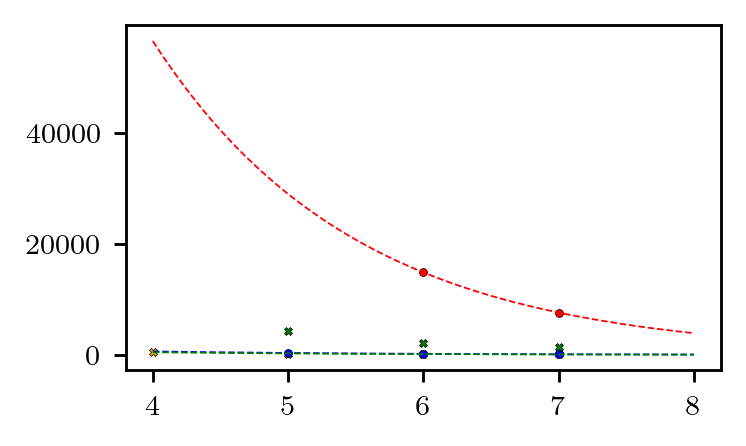

In [26]:

fig, ax = plt.subplots(1, 1, figsize=(3., 1.75), dpi=256)

markers = {1: 'v', 2: 'X', 3: 'o'}
colors = {128: 'blue', 256: 'red', 512: 'black', 1024: 'orange', 2048: 'green', 4096: 'gray'}
C = []

x_256, y_256 = [], []
x_128, y_128 = [], []
x_2048, y_2048 = [], []
x_1024, y_1024 = [], []

for s in SCALINGS:
    if s['N'] == 256:
        x_256.append(s['P'])
        y_256.append(s['T'])
    elif s['N'] == 128:
        x_128.append(s['P'])
        y_128.append(s['T'])
    elif s['N'] == 2048:
        x_2048.append(s['P'])
        y_2048.append(s['T'])
    elif s['N'] == 1024:
        x_1024.append(s['P'])
        y_1024.append(s['T'])
    else:
        continue
    ax.scatter(np.log2(s['P']), s['T'], marker=markers[s['D']], s=5., color=colors[s['N']], zorder=2, linewidth=0.2, edgecolor='black')

f_256 = np.polyfit(np.log(x_256), np.log(y_256), deg=1)
p_256 = np.poly1d(f_256)

f_128 = np.polyfit(np.log(x_128), np.log(y_128), deg=1)
p_128 = np.poly1d(f_128)

f_2048 = np.polyfit(np.log(x_2048), np.log(y_2048), deg=1)
p_2048 = np.poly1d(f_2048)

f_1024 = np.polyfit(np.log(x_1024), np.log(y_1024), deg=1)
p_1024 = np.poly1d(f_1024)

C = ['blue', 'red', 'green']
P = 10**np.linspace(np.log10(16), np.log10(256), 1000)
for i, f in enumerate([p_128, p_256, p_1024, p_2048]):
    ax.plot(np.log2(P), np.exp(f(np.log(P))), linewidth=0.5, linestyle='--', color=C[i])

props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
ax.text(5.5, 0.275, r'$128^3$', color='blue', transform=ax.get_xaxis_transform(), bbox=props, rotation=-5)
ax.text(5.5, 0.5, r'$2048^2$', color='green', transform=ax.get_xaxis_transform(), bbox=props, rotation=-5)
ax.text(5.5, 0.78, r'$256^3$', color='red', transform=ax.get_xaxis_transform(), bbox=props, rotation=-7.5)

ax.set_ylim((1e1, 1e5))

ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')

locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
ax.yaxis.set_major_locator(locmaj)
locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
ax.yaxis.set_minor_locator(locmin)

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Time, $T$ [s]')
ax.set_xlabel('\# Cores, $\log_2(P)$')


Estimated time: 431.52233959741574 [days]


Text(0.5, 0, 'Memory per core, $M$ [MiB]')

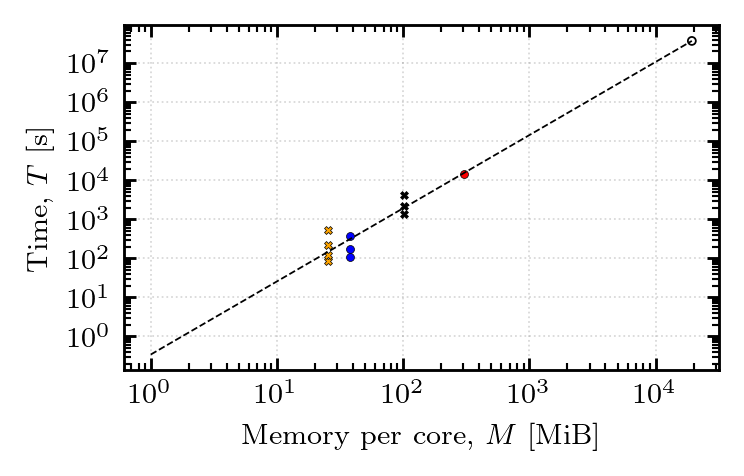

In [ ]:

def memory(s):
    if s['D'] == 2:
        M = (20 + 4)*(s['N']**s['D']) + 8*(s['N']/(s['P']//2) + s['N']*(s['P']//2)/s['P']) + 32*s['P']
    elif s['D'] == 3:
        M = (16 + 2)*(s['N']**s['D']) + 4*s['N']*s['N'] + 8*(s['N']/(s['P']//2) + s['N']*(s['P']//2)/s['P']) + 40*s['P']
    return M/1000/1000#*s['P']/1000

fig, ax = plt.subplots(1, 1, figsize=(3., 1.75), dpi=256)

markers = {1: 'v', 2: 'X', 3: 'o'}
colors = {128: 'blue', 256: 'red', 512: 'green', 1024: 'orange', 2048: 'black', 4096: 'gray'}

x_all, y_all = [], []

for s in SCALINGS:
    M = memory(s)
    x_all.append(M)
    y_all.append(s['T'])
    ax.scatter(M, s['T'], marker=markers[s['D']], color=colors[s['N']], s=5., zorder=2, linewidth=0.2, edgecolor='black')

est_big = memory({'D': 3, 'N': 1024, 'P': 128})

f_all = np.polyfit(np.log(x_all), np.log(y_all), 1)
p_all = np.poly1d(f_all)
M = 10**np.linspace(np.log10(1), np.log10(est_big), 1000)
ax.plot(M, np.exp(p_all(np.log(M))), color='black', linestyle='--', linewidth=0.5)

est_big = memory({'D': 3, 'N': 1024, 'P': 128})
ax.scatter(est_big, np.exp(p_all(np.log(est_big))), marker='o', s=5., color='none', zorder=2, linewidth=0.5, edgecolor='black')
print('Estimated time:', np.exp(p_all(np.log(est_big)))/60/60/24, '[days]')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')

locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
ax.yaxis.set_major_locator(locmaj)
locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
ax.yaxis.set_minor_locator(locmin)

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Time, $T$ [s]')
ax.set_xlabel('Memory per core, $M$ [MiB]')
